In [154]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_mall_customers_segmentation_path = kagglehub.dataset_download('abdallahwagih/mall-customers-segmentation')

print('Data source import complete.')


Using Colab cache for faster access to the 'mall-customers-segmentation' dataset.
Data source import complete.


In [155]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mall-customers-segmentation/Mall_Customers.csv


In [156]:
import os

# Load dataset
df = pd.read_csv(os.path.join(abdallahwagih_mall_customers_segmentation_path, 'Mall_Customers.csv'))

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [158]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [159]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [160]:
print(X)

     Age  Annual Income (k$)  Spending Score (1-100)
0     19                  15                      39
1     21                  15                      81
2     20                  16                       6
3     23                  16                      77
4     31                  17                      40
..   ...                 ...                     ...
195   35                 120                      79
196   45                 126                      28
197   32                 126                      74
198   32                 137                      18
199   30                 137                      83

[200 rows x 3 columns]


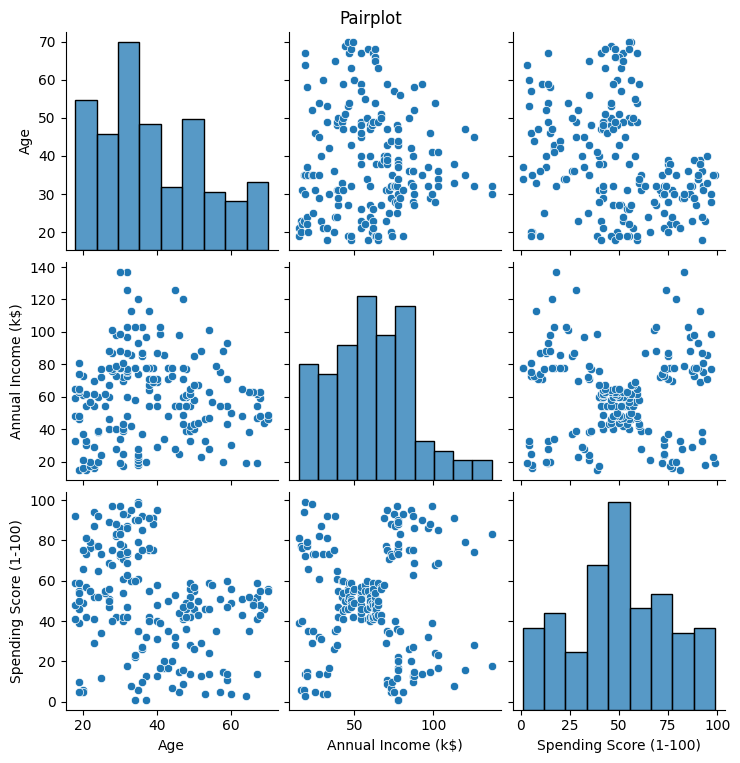

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(X)
plt.suptitle("Pairplot",y=1.01)
plt.show()

In [162]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

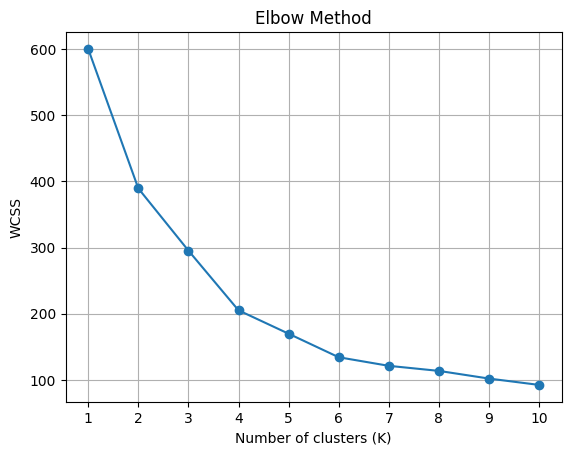

In [163]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [164]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=19)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

In [165]:
for k, score in zip(K_range, sil_scores):
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.335
K=3, Silhouette Score=0.315
K=4, Silhouette Score=0.310
K=5, Silhouette Score=0.411
K=6, Silhouette Score=0.429
K=7, Silhouette Score=0.420
K=8, Silhouette Score=0.408
K=9, Silhouette Score=0.411


In [166]:
kmeans = KMeans(n_clusters=6, random_state=19)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [167]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,25.250000,25.833333,76.916667
1,45.523810,26.285714,19.380952
2,32.692308,86.538462,82.128205
3,42.625000,89.437500,17.343750
4,56.333333,54.266667,49.066667
5,26.512821,57.974359,46.692308


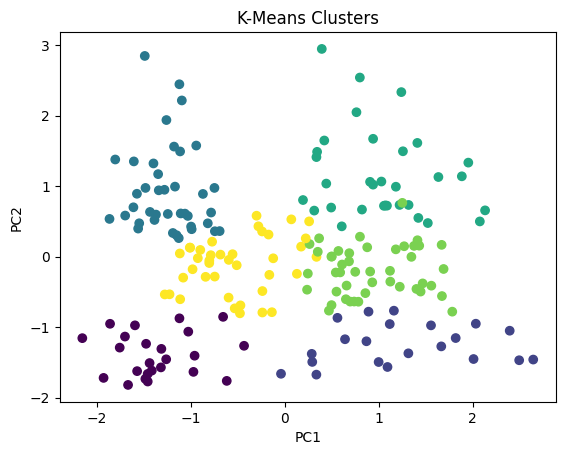

In [168]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [169]:
score = silhouette_score(X_scaled, kmeans.labels_)
print(f"Model's Silhouette Score = {score:.3f}")

Model's Silhouette Score = 0.429
